In [33]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

from pathlib import Path
train_transform = A.Compose([
    # --- Geometric (structure-preserving) ---
    A.Resize(256,512),
    A.Affine(
        scale=(0.8, 1.2),
        translate_percent=(-0.1, 0.1),
        rotate=(-10, 10),
        p=0.5
    ),
    A.Perspective(scale=(0.05, 0.1), p=0.3),  # simulate camera angle changes

    # --- Photometric / Color ---
    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3,
        p=0.5
    ),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=30,
        val_shift_limit=20,
        p=0.4
    ),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),  # adaptive histogram eq for low light

    # --- Weather / Lighting Simulation ---
    A.RandomShadow(
        shadow_roi=(0, 0.5, 1, 1),   # shadows only on road area
        num_shadows_lower=1,
        num_shadows_upper=3,
        shadow_dimension=5,
        p=0.4
    ),
    A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.15),
    A.RandomSunFlare(
        flare_roi=(0, 0, 1, 0.5),   # glare in upper half (sky/horizon)
        angle_lower=0.5,
        p=0.1
    ),

    # --- Noise / Blur (simulate camera quality) ---
    A.OneOf([
        A.MotionBlur(blur_limit=5, p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.2),
    A.GaussNoise(var_limit=(10, 50), p=0.2),
    A.ImageCompression(quality_lower=75, quality_upper=95, p=0.2),

    # --- Normalize & Convert ---
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'binary_mask': 'mask', 'instance_mask': 'mask'})

/var/folders/4m/b6_cz0w13g31tffdygtbhty00000gn/T/ipykernel_81779/492487640.py:32: UserWarning: Argument(s) 'num_shadows_lower, num_shadows_upper' are not valid for transform RandomShadow
  A.RandomShadow(
/var/folders/4m/b6_cz0w13g31tffdygtbhty00000gn/T/ipykernel_81779/492487640.py:39: UserWarning: Argument(s) 'fog_coef_lower, fog_coef_upper' are not valid for transform RandomFog
  A.RandomFog(fog_coef_lower=0.1, fog_coef_upper=0.3, p=0.15),
/var/folders/4m/b6_cz0w13g31tffdygtbhty00000gn/T/ipykernel_81779/492487640.py:40: UserWarning: Argument(s) 'angle_lower' are not valid for transform RandomSunFlare
  A.RandomSunFlare(
/var/folders/4m/b6_cz0w13g31tffdygtbhty00000gn/T/ipykernel_81779/492487640.py:52: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),
/var/folders/4m/b6_cz0w13g31tffdygtbhty00000gn/T/ipykernel_81779/492487640.py:53: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform Ima

In [34]:
import os
import random

folder_path = Path("/Users/amannindra/Projects/Autonomous-Bicycle/LaneNet/TUSimple/train_set/training/gt_image")
file_names = []

# os.walk yields a tuple: (current_path, subdirectories, files) for each folder it visits
for root, dirs, files in os.walk(folder_path):
    print(root)
    print(dirs)
    # print(files)
    for file in files:
        file_names.append(os.path.join(folder_path, file))
    break

print(len(file_names))


/Users/amannindra/Projects/Autonomous-Bicycle/LaneNet/TUSimple/train_set/training/gt_image
[]
3626


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.2885153].


1232
torch.Size([512, 256, 3])


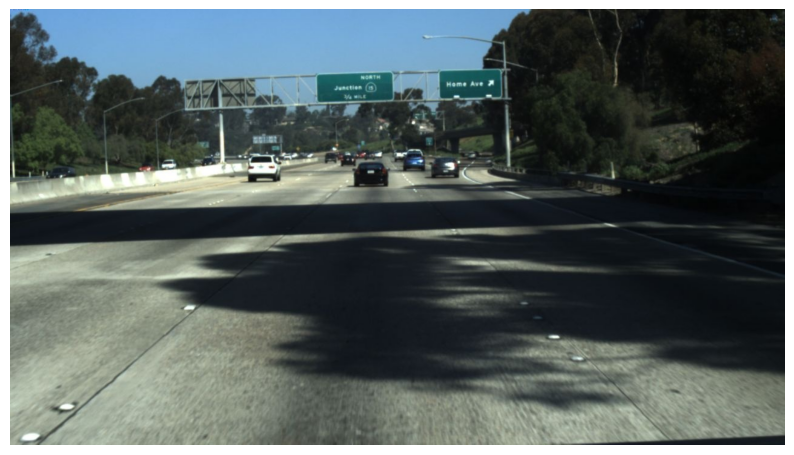

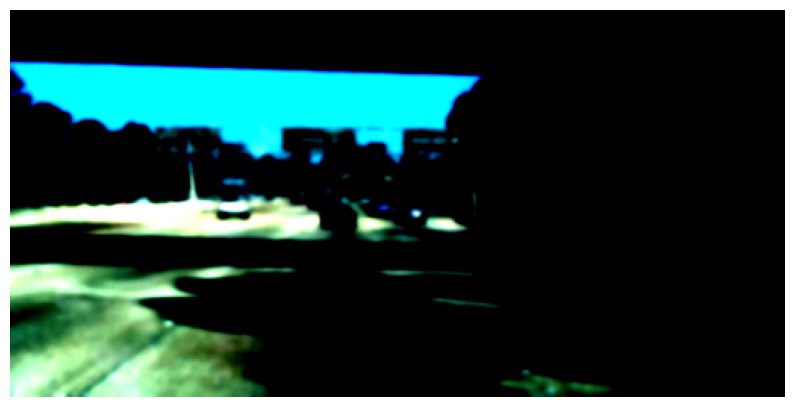

In [35]:
from PIL import Image
import numpy as np


num = random.randint(0, len(file_names))
print(num)

image_set = Image.open(file_names[num])
from matplotlib import pyplot as plt


def visualize(image):
    plt.figure(figsize=(10, 10))
    plt.axis("off")
    plt.imshow(image)
visualize(image_set)
augmented_image = train_transform(image=np.array(image_set))['image'].T
print(augmented_image.shape)
visualize(augmented_image.permute(1, 0, 2).numpy())